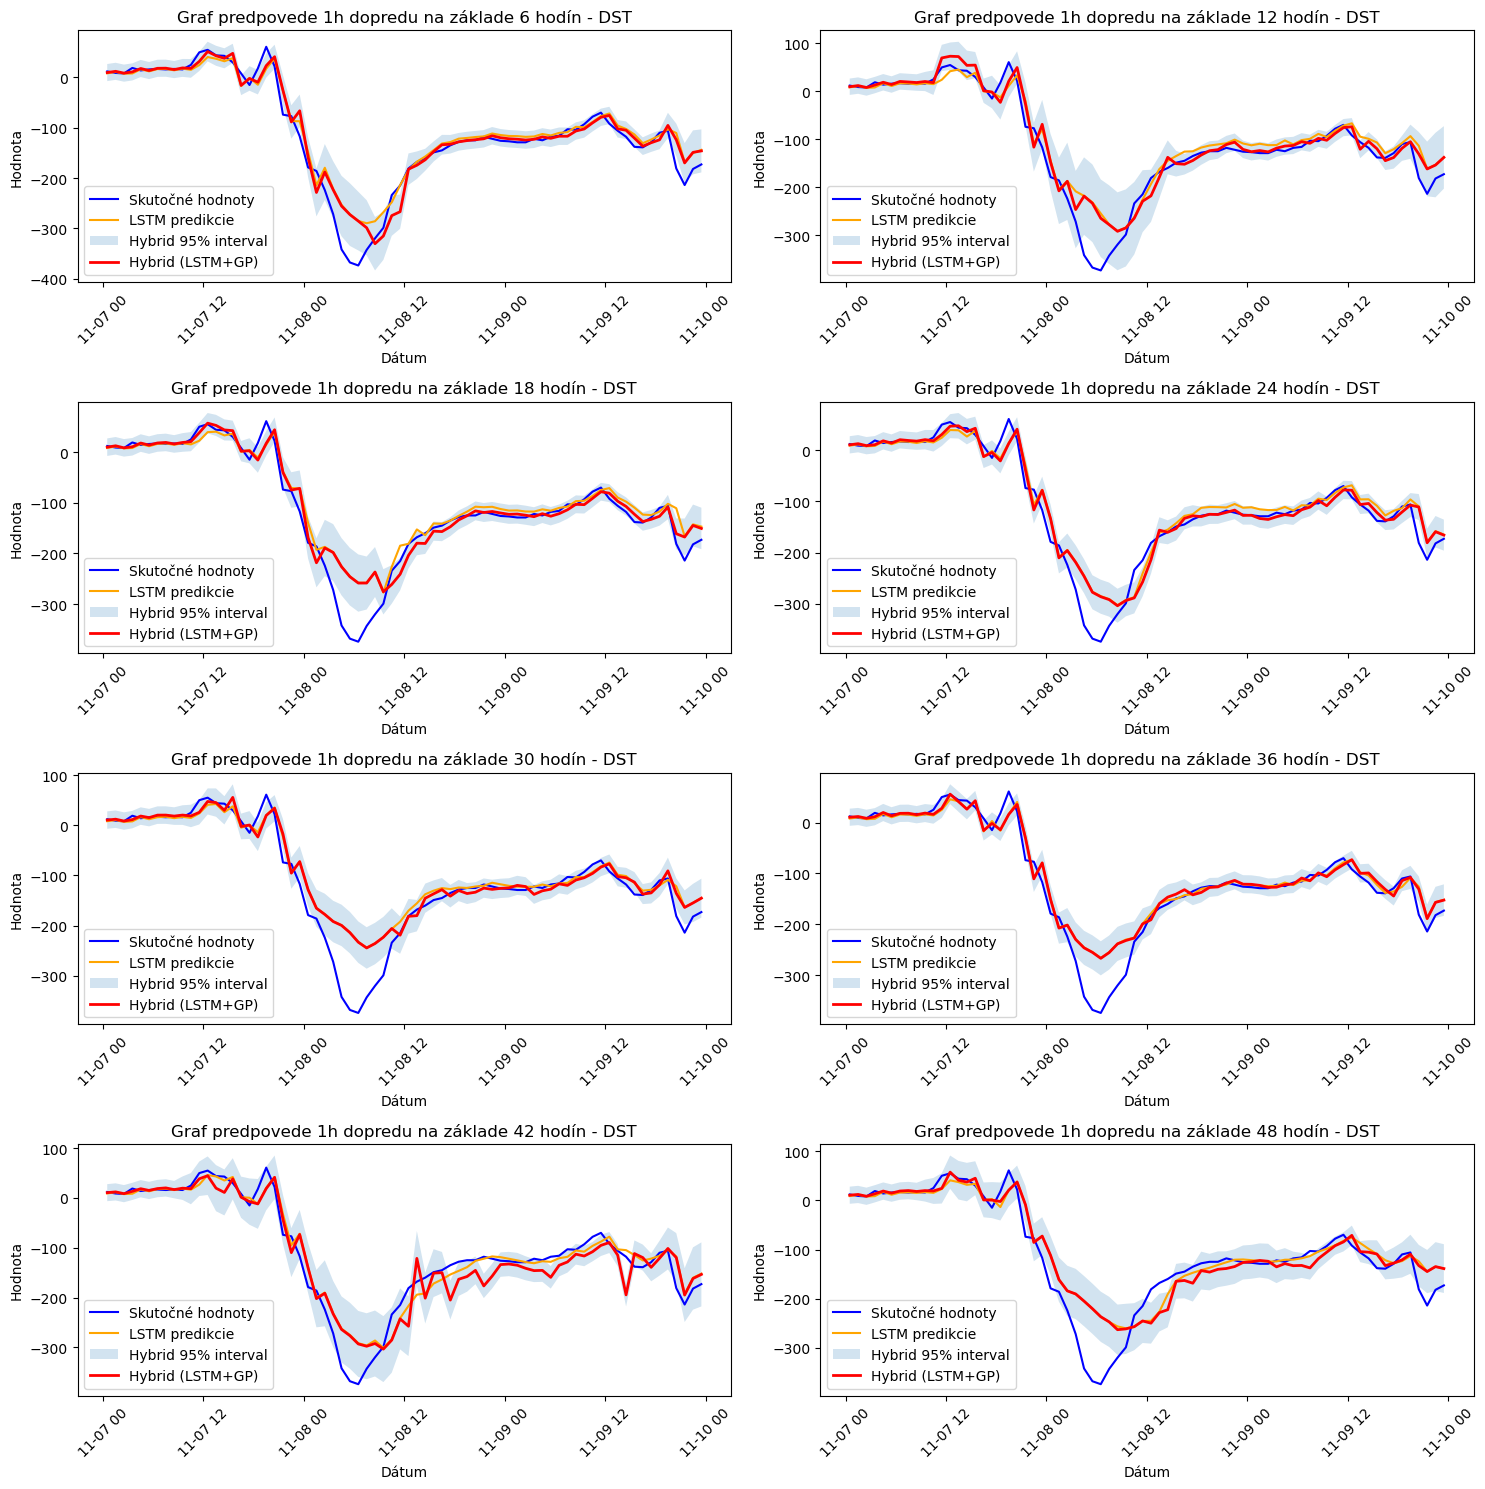

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# Define the date range
start_date = '2004-11-07'
end_date = '2004-11-10'

# Function to load and filter dataframes from CSV files
def load_dataframes(extension):
    dataframes = []
    for i in range(6, 49, 6):
        filename = f'V+BZ_GSM/prediction_comparison_DST+1{extension}{i}H.csv'
        df = pd.read_csv(filename, parse_dates=['time'])
        # Filter by the specified date range
        df = df[(df['time'] >= start_date) & (df['time'] <= end_date)]
        dataframes.append(df)
    return dataframes

# Load data for original predictions
dataframes = load_dataframes('_LSTM_')

# Plotting the combined graph
fig, axes = plt.subplots(nrows=4, ncols=2, figsize=(15, 15))
axes = axes.flatten()

for i in range(8):
    ax = axes[i]
    ax.plot(dataframes[i]['time'], dataframes[i]['y_true'], label='Skutočné hodnoty', color="blue")
    ax.plot(dataframes[i]['time'], dataframes[i]['y_lstm'], label='LSTM predikcie', color="orange")
    ax.fill_between(dataframes[i]["time"], dataframes[i]["hybrid_lower"], dataframes[i]["hybrid_upper"], alpha=0.2, label="Hybrid 95% interval")
    ax.plot(dataframes[i]["time"], dataframes[i]["y_hybrid"], label="Hybrid (LSTM+GP)", linewidth=2, color="red")
    ax.set_title(f'Graf predpovede 1h dopredu na základe {(i+1)*6} hodín - DST')
    ax.set_xlabel('Dátum')
    ax.set_ylabel('Hodnota')
    ax.legend()
    ax.tick_params(axis='x', rotation=45)

plt.tight_layout()
plt.savefig("/tmp/rozne_dlzky_okna_DST+1.png") 
plt.show()